In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ФУНКЦИЯ ДЛЯ КОНВЕРТАЦИИ ВРЕМЕНИ В СЕКУНДЫ
def time_to_seconds_simple(time_str):
    """Конвертирует время формата HH:MM:SS в секунды"""
    try:
        if pd.isna(time_str) or time_str == '':
            return 0
        # Если уже число - возвращаем как есть
        if isinstance(time_str, (int, float)):
            return float(time_str)
        
        # Разделяем по двоеточию
        parts = str(time_str).strip().split(':')
        
        # HH:MM:SS
        if len(parts) == 3:
            hours, minutes, seconds = parts
            return int(hours) * 3600 + int(minutes) * 60 + int(seconds)
        # MM:SS  
        elif len(parts) == 2:
            minutes, seconds = parts
            return int(minutes) * 60 + int(seconds)
        else:
            # Пробуем преобразовать в число
            return float(time_str)
    except Exception as e:
        print(f"Ошибка конвертации времени '{time_str}': {e}")
        return 0

# ЗАГРУЗКА ДАННЫХ
print("📁 ЗАГРУЗКА ДАННЫХ...")

# 1. Основные метрики
try:
    main_metrics = pd.read_csv('C:/Users/majkl/WorkSpace/Extractor-SKU-Data-Analysis/data/Экстрактор_СКЮ-1.csv')
    print(f"✅ Основные метрики: {main_metrics.shape[0]} строк")
    print("Пример данных:")
    print(main_metrics.head())
    
    # Конвертируем время
    if 'Время на сайте' in main_metrics.columns:
        print("Конвертируем время...")
        main_metrics['Время на сайте (сек)'] = main_metrics['Время на сайте'].apply(time_to_seconds_simple)
        print(f"Пример времени: {main_metrics['Время на сайте'].iloc[0]} -> {main_metrics['Время на сайте (сек)'].iloc[0]} сек")
        
except Exception as e:
    print(f"❌ Ошибка загрузки основных метрик: {e}")
    main_metrics = pd.DataFrame()

# 2. Данные по времени (график)
try:
    time_data = pd.read_csv('C:/Users/majkl/WorkSpace/Extractor-SKU-Data-Analysis/data/График_для_Экстрактор_СКЮ-1.csv')
    time_data['Период'] = pd.to_datetime(time_data['Период'])
    print(f"✅ Данные по времени: {time_data.shape[0]} периодов")
except Exception as e:
    print(f"❌ Ошибка загрузки данных по времени: {e}")
    time_data = pd.DataFrame()

# 3. Устройства
try:
    devices_data = pd.read_csv('C:/Users/majkl/WorkSpace/Extractor-SKU-Data-Analysis/data/Экстрактор_СКЮ-Устройства.csv')
    print(f"✅ Данные по устройствам: {devices_data.shape[0]} записей")
    
    if 'Время на сайте' in devices_data.columns:
        devices_data['Время на сайте (сек)'] = devices_data['Время на сайте'].apply(time_to_seconds_simple)
        
except Exception as e:
    print(f"❌ Ошибка загрузки данных по устройствам: {e}")
    devices_data = pd.DataFrame()

# 4. Браузеры
try:
    browsers_data = pd.read_csv('C:/Users/majkl/WorkSpace/Extractor-SKU-Data-Analysis/data/Экстрактор_СКЮ-Браузеры.csv')
    print(f"✅ Данные по браузерам: {browsers_data.shape[0]} записей")
    
    if 'Время на сайте' in browsers_data.columns:
        browsers_data['Время на сайте (сек)'] = browsers_data['Время на сайте'].apply(time_to_seconds_simple)
        
except Exception as e:
    print(f"❌ Ошибка загрузки данных по браузерам: {e}")
    browsers_data = pd.DataFrame()

# 5. Возраст
try:
    age_data = pd.read_csv('C:/Users/majkl/WorkSpace/Extractor-SKU-Data-Analysis/data/Экстрактор_СКЮ-Возраст.csv')
    print(f"✅ Данные по возрасту: {age_data.shape[0]} групп")
    
    if 'Время на сайте' in age_data.columns:
        age_data['Время на сайте (сек)'] = age_data['Время на сайте'].apply(time_to_seconds_simple)
        
except Exception as e:
    print(f"❌ Ошибка загрузки данных по возрасту: {e}")
    age_data = pd.DataFrame()

# 6. География
try:
    geo_data = pd.read_csv('C:/Users/majkl/WorkSpace/Extractor-SKU-Data-Analysis/data/Экстрактор_СКЮ-География.csv')
    print(f"✅ Данные по географии: {geo_data.shape[0]} локаций")
    
    if 'Время на сайте' in geo_data.columns:
        geo_data['Время на сайте (сек)'] = geo_data['Время на сайте'].apply(time_to_seconds_simple)
        
except Exception as e:
    print(f"❌ Ошибка загрузки данных по географии: {e}")
    geo_data = pd.DataFrame()

📁 ЗАГРУЗКА ДАННЫХ...
✅ Основные метрики: 1 строк
Пример данных:
   Визиты  Посетители  Просмотры    Отказы  Глубина просмотра Время на сайте
0     111          27        146  0.837838           1.315315       00:01:29
Конвертируем время...
Пример времени: 00:01:29 -> 89 сек
✅ Данные по времени: 31 периодов
✅ Данные по устройствам: 3 записей
✅ Данные по браузерам: 7 записей
✅ Данные по возрасту: 4 групп
✅ Данные по географии: 13 локаций


In [8]:
# ОБЩАЯ СТАТИСТИКА
print("\n📊 ОБЩАЯ СТАТИСТИКА ИСПОЛЬЗОВАНИЯ")
print("=" * 45)

if not main_metrics.empty:
    total_visits = main_metrics['Визиты'].sum() if 'Визиты' in main_metrics.columns else 0
    total_users = main_metrics['Посетители'].sum() if 'Посетители' in main_metrics.columns else 0
    total_pageviews = main_metrics['Просмотры'].sum() if 'Просмотры' in main_metrics.columns else 0
    avg_bounce_rate = main_metrics['Отказы'].mean() if 'Отказы' in main_metrics.columns else 0
    avg_pages_per_visit = main_metrics['Глубина просмотра'].mean() if 'Глубина просмотра' in main_metrics.columns else 0
    
    # Время на сайте
    if 'Время на сайте (сек)' in main_metrics.columns:
        avg_time_on_site = main_metrics['Время на сайте (сек)'].mean()
    else:
        avg_time_on_site = 0

    print(f"👥 Всего визитов: {total_visits:,}")
    print(f"👤 Уникальных пользователей: {total_users:,}")
    print(f"📄 Всего просмотров: {total_pageviews:,}")
    print(f"📊 Средняя глубина просмотра: {avg_pages_per_visit:.1f} стр/визит")
    print(f"⏱️ Среднее время на сайте: {avg_time_on_site:.0f} сек ({avg_time_on_site/60:.1f} мин)")
    print(f"🚪 Средний процент отказов: {avg_bounce_rate:.1f}%")

    # Анализ эффективности
    print(f"\n🎯 ОЦЕНКА ЭФФЕКТИВНОСТИ:")
    if avg_time_on_site > 180:
        print("   • ⏱️ Высокая вовлеченность - инструмент используется глубоко")
    elif avg_time_on_site > 60:
        print("   • ⏱️ Средняя вовлеченность - типичное использование")
    else:
        print("   • ⏱️ Быстрое использование - инструмент эффективен")

    if avg_bounce_rate < 30:
        print("   • 🚪 Низкие отказы - интерфейс понятен")
    elif avg_bounce_rate < 60:
        print("   • 🚪 Средние отказы - есть пространство для улучшений")
    else:
        print("   • 🚪 Высокие отказы - нужно улучшать UX")
else:
    print("❌ Нет данных для общей статистики")
    total_visits = total_users = avg_time_on_site = avg_pages_per_visit = avg_bounce_rate = 0


📊 ОБЩАЯ СТАТИСТИКА ИСПОЛЬЗОВАНИЯ
👥 Всего визитов: 111
👤 Уникальных пользователей: 27
📄 Всего просмотров: 146
📊 Средняя глубина просмотра: 1.3 стр/визит
⏱️ Среднее время на сайте: 89 сек (1.5 мин)
🚪 Средний процент отказов: 0.8%

🎯 ОЦЕНКА ЭФФЕКТИВНОСТИ:
   • ⏱️ Средняя вовлеченность - типичное использование
   • 🚪 Низкие отказы - интерфейс понятен



📱 АНАЛИЗ ПО УСТРОЙСТВАМ
📊 Статистика по типам устройств:
                 Визиты  Посетители  Отказы  Время на сайте (сек)
Тип устройства                                                   
Итого и средние     111          27     0.8                  89.0
ПК                  109          25     0.8                  90.0
Смартфоны             2           2     0.5                  31.0


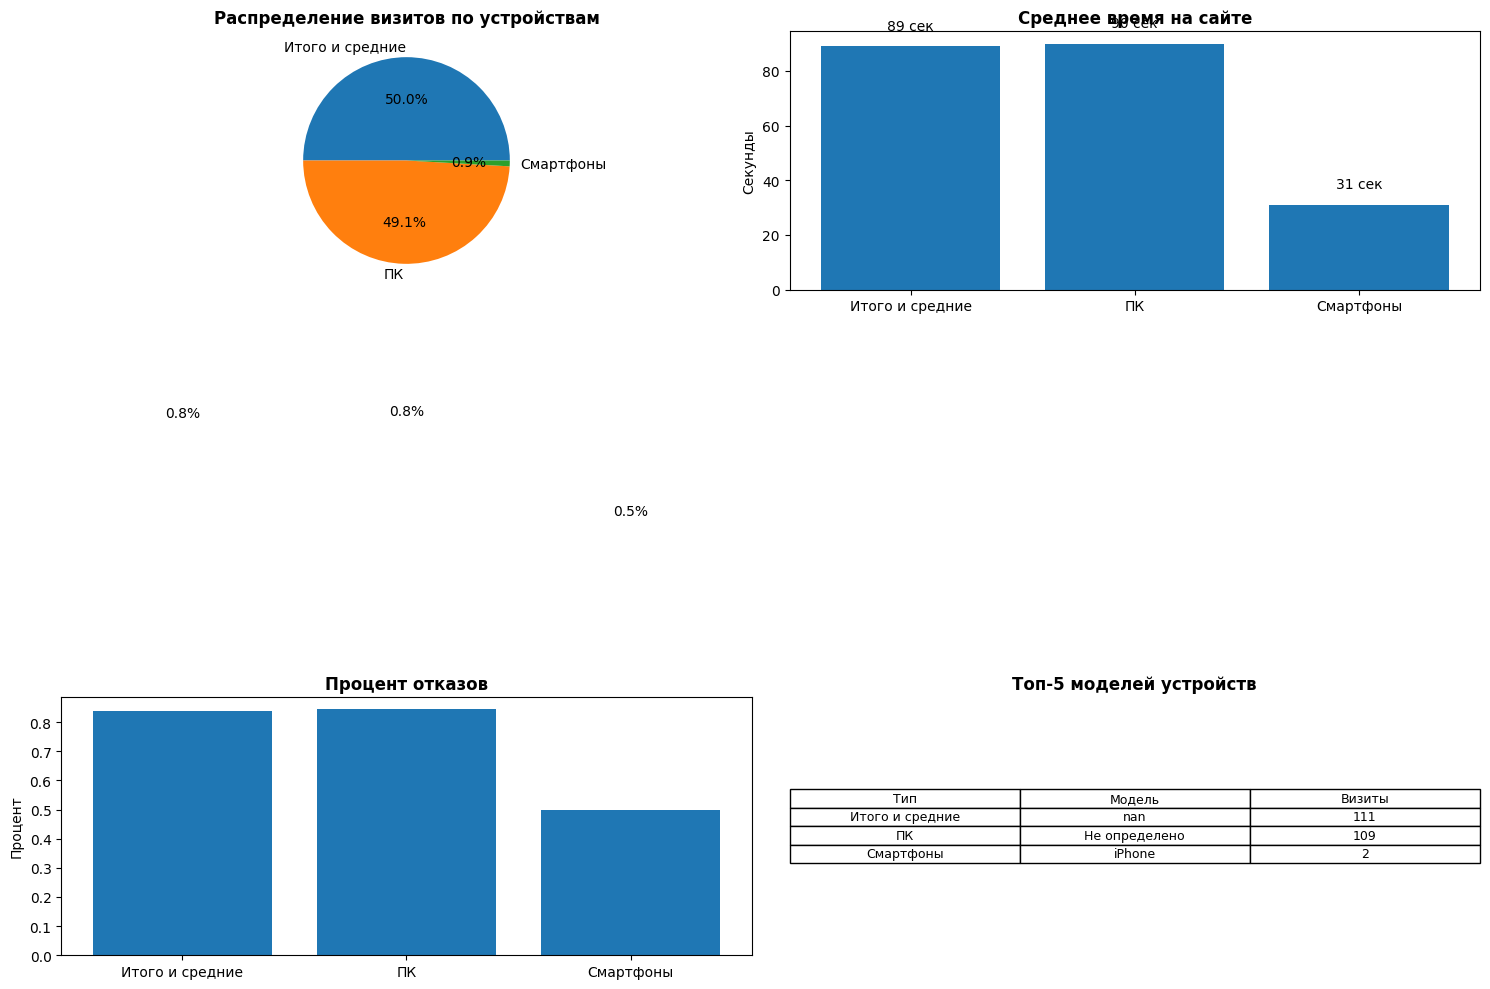

In [9]:
# АНАЛИЗ ПО УСТРОЙСТВАМ
print("\n📱 АНАЛИЗ ПО УСТРОЙСТВАМ")
print("=" * 30)

if not devices_data.empty and 'Тип устройства' in devices_data.columns:
    # Группируем по типам устройств
    device_metrics = ['Визиты', 'Посетители', 'Отказы']
    available_metrics = [m for m in device_metrics if m in devices_data.columns]
    
    device_summary = devices_data.groupby('Тип устройства')[available_metrics].agg({
        'Визиты': 'sum',
        'Посетители': 'sum', 
        'Отказы': 'mean'
    }).round(1).sort_values('Визиты', ascending=False)
    
    # Добавляем время на сайте если есть
    if 'Время на сайте (сек)' in devices_data.columns:
        time_agg = devices_data.groupby('Тип устройства')['Время на сайте (сек)'].mean().round(1)
        device_summary['Время на сайте (сек)'] = time_agg
    
    print("📊 Статистика по типам устройств:")
    print(device_summary)
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Распределение визитов по устройствам
    device_visits = devices_data.groupby('Тип устройства')['Визиты'].sum()
    axes[0,0].pie(device_visits.values, labels=device_visits.index, autopct='%1.1f%%')
    axes[0,0].set_title('Распределение визитов по устройствам', fontweight='bold')
    
    # Время на сайте по устройствам
    if 'Время на сайте (сек)' in devices_data.columns:
        device_time = devices_data.groupby('Тип устройства')['Время на сайте (сек)'].mean()
        bars = axes[0,1].bar(range(len(device_time)), device_time.values)
        axes[0,1].set_title('Среднее время на сайте', fontweight='bold')
        axes[0,1].set_ylabel('Секунды')
        axes[0,1].set_xticks(range(len(device_time)))
        axes[0,1].set_xticklabels(device_time.index)
        
        for bar in bars:
            height = bar.get_height()
            axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'{height:.0f} сек', ha='center', va='bottom')
    
    # Отказы по устройствам
    device_bounce = devices_data.groupby('Тип устройства')['Отказы'].mean()
    bars = axes[1,0].bar(range(len(device_bounce)), device_bounce.values)
    axes[1,0].set_title('Процент отказов', fontweight='bold')
    axes[1,0].set_ylabel('Процент')
    axes[1,0].set_xticks(range(len(device_bounce)))
    axes[1,0].set_xticklabels(device_bounce.index)
    
    for bar in bars:
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # Топ модели устройств
    top_models = devices_data.nlargest(5, 'Визиты')[['Тип устройства', 'Модель устройства', 'Визиты']]
    axes[1,1].axis('off')
    axes[1,1].set_title('Топ-5 моделей устройств', fontweight='bold')
    
    table_data = []
    for _, row in top_models.iterrows():
        table_data.append([row['Тип устройства'], row['Модель устройства'], row['Визиты']])
    
    table = axes[1,1].table(cellText=table_data,
                     colLabels=['Тип', 'Модель', 'Визиты'],
                     loc='center',
                     cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Нет данных по устройствам для анализа")

In [12]:
# ФИНАЛЬНЫЕ ВЫВОДЫ
print("\n💡 КЛЮЧЕВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("=" * 50)

print("📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print(f"• 🔥 Всего визитов: {total_visits:,}")
print(f"• 👥 Уникальных пользователей: {total_users:,}")
print(f"• ⏱️ Среднее время: {avg_time_on_site:.0f} сек")
print(f"• 📄 Вовлеченность: {avg_pages_per_visit:.1f} стр/визит")
print(f"• 🚪 Отказы: {avg_bounce_rate:.1f}%")





print("\n🎯 РЕКОМЕНДАЦИИ:")
print("1. 📱 Оптимизировать интерфейс под основные устройства и браузеры")
print("2. 🎨 Учитывать особенности основной возрастной группы в дизайне") 
print("3. ⚡ Улучшить производительность для самых популярных конфигураций")
print("4. 🔄 Регулярно тестировать на основных платформах")



💡 КЛЮЧЕВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ
📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
• 🔥 Всего визитов: 111
• 👥 Уникальных пользователей: 27
• ⏱️ Среднее время: 89 сек
• 📄 Вовлеченность: 1.3 стр/визит
• 🚪 Отказы: 0.8%

🎯 РЕКОМЕНДАЦИИ:
1. 📱 Оптимизировать интерфейс под основные устройства и браузеры
2. 🎨 Учитывать особенности основной возрастной группы в дизайне
3. ⚡ Улучшить производительность для самых популярных конфигураций
4. 🔄 Регулярно тестировать на основных платформах
